## QRT — Asset Allocation Performance forecasting

### 1. Problème et définitions de l'énoncé

Une ligne associe une date et une allocation rééquilibrée quotidiennement. L'historique couvre 20 séances. Prédire le signe du rendement suivant : **classe 1 si `target > 0`, sinon 0**. L'accuracy évalue le signe.

Dates `TS` anonymisées et mélangées ; identité `ALLOCATION` persistante ; catégorie `GROUP` anonymisée. Décalage des historiques : `1` désigne la séance la plus récente.

Pour l'allocation $S$, les actifs $j$ et la date $t$ :

$$
\begin{aligned}
\sum_{j=1}^{M}|w_{S,t,j}| &= 1 \\
r_{S,t+1} &= \sum_{j=1}^{M}w_{S,t,j}\,r_{j,t+1} \\
V_{S,t} &= \sum_{j=1}^{M}w_{S,t,j}\,V_{j,t} \\
TO_{S,t} &= \sum_{j=1}^{M}|w_{S,t,j}-w_{S,t-1,j}| \\
MDT_{S,t} &= \operatorname{median}(TO_{S,t},\ldots,TO_{S,t-20})
\end{aligned}
$$

$w$ : poids signés ; $r$ : rendements ; $V_{j,t}$ : volumes de marché. Les volumes agrégés sont ensuite normalisés sur fenêtre glissante. La formule de `MEDIAN_DAILY_TURNOVER` contient **21 termes**.

Non précisés : calendrier réel, actifs, sens économique des groupes, mécanisme des absences, normalisation exacte, coûts.

Benchmark public LightGBM : **0,5079**.

L'[énoncé officiel](https://challengedata.ens.fr/challenges/167) reste la référence pour ces définitions. Avec $c_i=\mathbf{1}[y_i>0]$ et une prédiction binaire $\hat c_i$, la métrique s'écrit :

$$
\mathrm{accuracy}=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}[\hat c_i=c_i].
$$

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from pathlib import Path
from qrt.data import load_tr_data


In [21]:
X_train, y_train = load_tr_data(Path("../data/raw"))

print(X_train.shape, y_train.shape)
print(X_train.index.equals(y_train.index))

(527073, 44) (527073, 1)
True


In [22]:
X_train.head()

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [23]:
y_train.head()

,target
ROW_ID,
0,0.009210
1,0.000405
2,0.005967
3,-0.000542
4,-0.002579


### Heuristic baseline

In [25]:
target = y_train["target"].dropna()
target_class = (target > 0).astype(int)
class_proportions = target_class.value_counts(normalize=True)
print("Number of positive samples:", class_proportions[1])
print("Number of negative samples:", class_proportions[0])

Number of positive samples: 0.5071840143585423
Number of negative samples: 0.4928159856414576


Predict positive give a 0.507 accuracy as a simple baseline

### Variables diag

In [32]:
ret_cat = ["RET_{i}".format(i=i) for i in range(1, 21)]
sign_volume_cat = ["SIGNED_VOLUME_{i}".format(i=i) for i in range(1, 21)]
turnover_cat = ["MEDIAN_DAILY_TURNOVER"]

diag = dict()
for col in ret_cat + sign_volume_cat + turnover_cat:
    diag[col] = dict()
    diag[col]["missing_pct"] = X_train[col].isna().sum() / len(X_train) * 100
    diag[col]["mean"] = X_train[col].mean()
    diag[col]["std"] = X_train[col].std()
    diag[col]["min"] = X_train[col].min()
    diag[col]["p01"] = X_train[col].quantile(0.01)
    diag[col]["median"] = X_train[col].median()
    diag[col]["p99"] = X_train[col].quantile(0.99)
    diag[col]["max"] = X_train[col].max()

pd.DataFrame(diag).T


,missing_pct,mean,std,min,p01,median,p99,max
RET_1,0.000000,0.000079,0.003041,-3.935147e-02,-0.008180,0.000062,0.008245,0.129314
RET_2,0.000000,0.000042,0.003068,-4.372330e-02,-0.008343,0.000038,0.008269,0.129412
RET_3,0.000000,0.000038,0.003058,-4.367603e-02,-0.008340,0.000038,0.008277,0.129798
RET_4,0.000000,0.000034,0.003051,-4.235460e-02,-0.008331,0.000035,0.008226,0.131141
RET_5,0.000000,0.000032,0.003042,-4.362071e-02,-0.008291,0.000035,0.008208,0.129787
RET_6,0.000000,0.000028,0.003047,-4.356928e-02,-0.008295,0.000032,0.008185,0.130090
RET_7,0.000000,0.000026,0.003048,-4.407607e-02,-0.008308,0.000031,0.008181,0.129792
RET_8,0.000000,0.000026,0.003047,-4.365150e-02,-0.008344,0.000029,0.008185,0.129302
RET_9,0.000000,0.000026,0.003049,-4.343652e-02,-0.008341,0.000030,0.008192,0.129456
RET_10,0.000379,0.000023,0.003056,-4.620820e-02,-0.008358,0.000028,0.008179,0.129320


`SIGNED_VOLUME_1` manque sur **73,52 %** des lignes | Sa disponibilité mérite une investigation.

L’écart-type de `RET_1` est ≈ **0,003**, celui de `SIGNED_VOLUME_2` ≈ **1,58** | Les familles ont des échelles très différentes.

Pour `SIGNED_VOLUME_2`, les quantiles 1–99 % vont d’environ **−4,02 à +3,80**, mais les extrêmes atteignent **−115,23 et +78,66** | Quelques valeurs sont très éloignées du centre de la distribution.

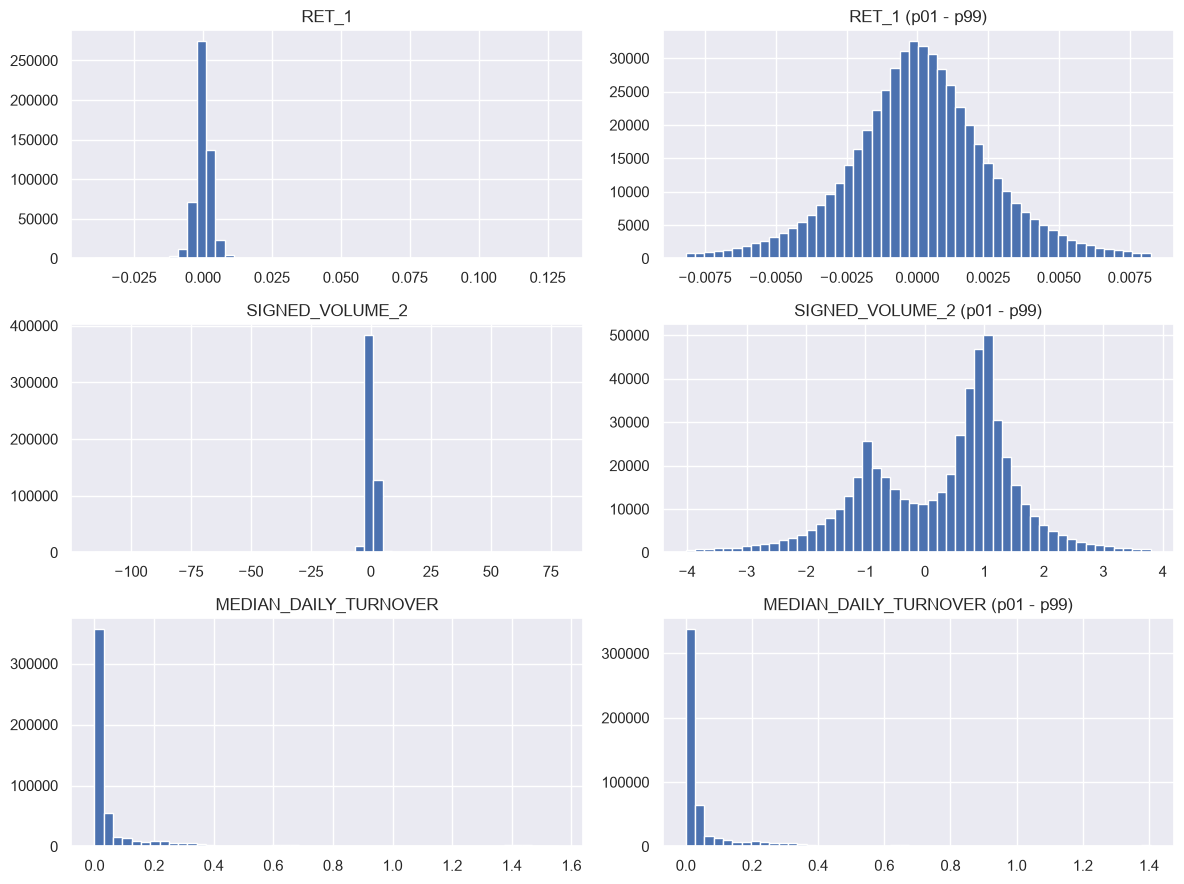

In [38]:
columns = ["RET_1", "SIGNED_VOLUME_2", "MEDIAN_DAILY_TURNOVER"]
fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for i, column in enumerate(columns):
    values = X_train[column].dropna()
    p01, p99 = values.quantile([0.01, 0.99])

    axes[i, 0].hist(values, bins=50)
    axes[i, 0].set_title(f"{column}")

    axes[i, 1].hist(values[values.between(p01, p99)], bins=50)
    axes[i, 1].set_title(f"{column} (p01 - p99)")

plt.tight_layout()
plt.show()


- **`RET_1` :** la distribution est concentrée près de zéro, avec environ 98 % des valeurs entre −0,818 % et +0,824 %, mais quelques rendements beaucoup plus éloignés, jusqu'à +12,93 %.
- **`SIGNED_VOLUME_2` :** le zoom révèle deux pics autour de −1 et +1, difficiles à distinguer dans la vue complète à cause des extrêmes proches de −115 et +79.
- **`MEDIAN_DAILY_TURNOVER` :** les valeurs sont fortement concentrées près de zéro (médiane ≈ 0,0159), avec une distribution asymétrique vers la droite et des concentrations secondaires visibles sur la vue logarithmique.

**Décision à ce stade :** ces graphiques décrivent les données, mais ne suffisent pas à identifier des erreurs ; on conserve les valeurs et on examinera le contexte des extrêmes avant de décider d'un éventuel traitement.


In [39]:
na_sv_grouped = X_train.groupby("GROUP")["SIGNED_VOLUME_1"].apply(lambda x: x.isna().sum() / len(x) * 100)
na_sv_grouped

GROUP
1    74.689029
2    73.471036
3    73.130546
4    73.158245
Name: SIGNED_VOLUME_1, dtype: float64

In [57]:
na_sv_ts = X_train.groupby("TS")["SIGNED_VOLUME_1"].apply(lambda x: x.isna().sum() / len(x) * 100)
na_sv_ts.sort_values(ascending=False)
missing_count = sum([1 for c in na_sv_ts.index if na_sv_ts[c] > 0])
missing_count / len(na_sv_ts)

0.8009516256938938

In [64]:
na_sv_ts_missing = X_train.loc[X_train["TS"].isin(na_sv_ts[na_sv_ts > 0].index)]
na_sv_alloc = na_sv_ts_missing.groupby("ALLOCATION")["SIGNED_VOLUME_1"].apply(lambda x: x.isna().sum() / len(x) * 100)
na_sv_alloc.sort_values(ascending=False)

ALLOCATION
ALLOCATION_01     100.0
ALLOCATION_261    100.0
ALLOCATION_247    100.0
ALLOCATION_248    100.0
ALLOCATION_249    100.0
                  ...  
ALLOCATION_111      0.0
ALLOCATION_257      0.0
ALLOCATION_113      0.0
ALLOCATION_72       0.0
ALLOCATION_156      0.0
Name: SIGNED_VOLUME_1, Length: 278, dtype: float64

In [65]:
pd.Series({
    "Duplicate ROW_IDs": X_train.index.duplicated().sum(),
    "Duplicate (TS, ALLOCATION)": X_train.duplicated(["TS", "ALLOCATION"]).sum(),
    "Infinite values": np.isinf(X_train.select_dtypes("number")).sum().sum(),
    "Missing targets": y_train["target"].isna().sum(),
}, name="count").to_frame()

,count
Duplicate ROW_IDs,0
"Duplicate (TS, ALLOCATION)",0
Infinite values,0
Missing targets,0


Notre décision est donc de préserver les observations, pour éviter de perdre 73,5 % des lignes à cause d’une seule colonne. L’intérêt de conserver cette colonne dans le modèle reste à vérifier sur la validation : ce sont deux décisions différentes.

### Behaviours

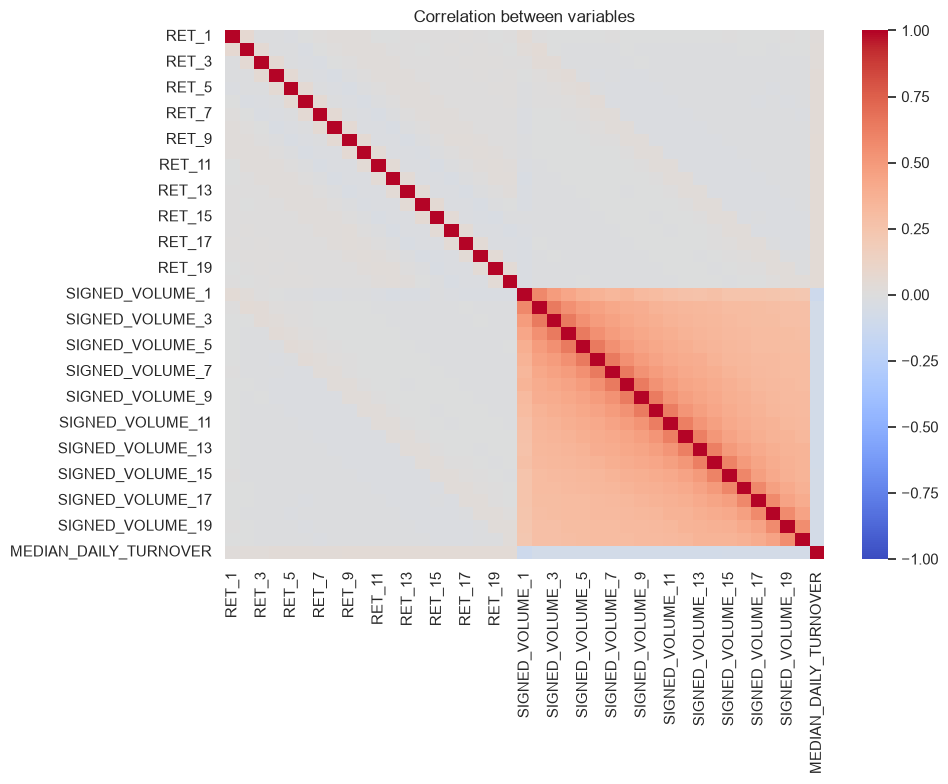

In [76]:
columns = ret_cat + sign_volume_cat + turnover_cat

plt.figure(figsize=(10, 8))
sns.heatmap(X_train[columns].corr(), cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation between variables")
plt.tight_layout()
plt.show()

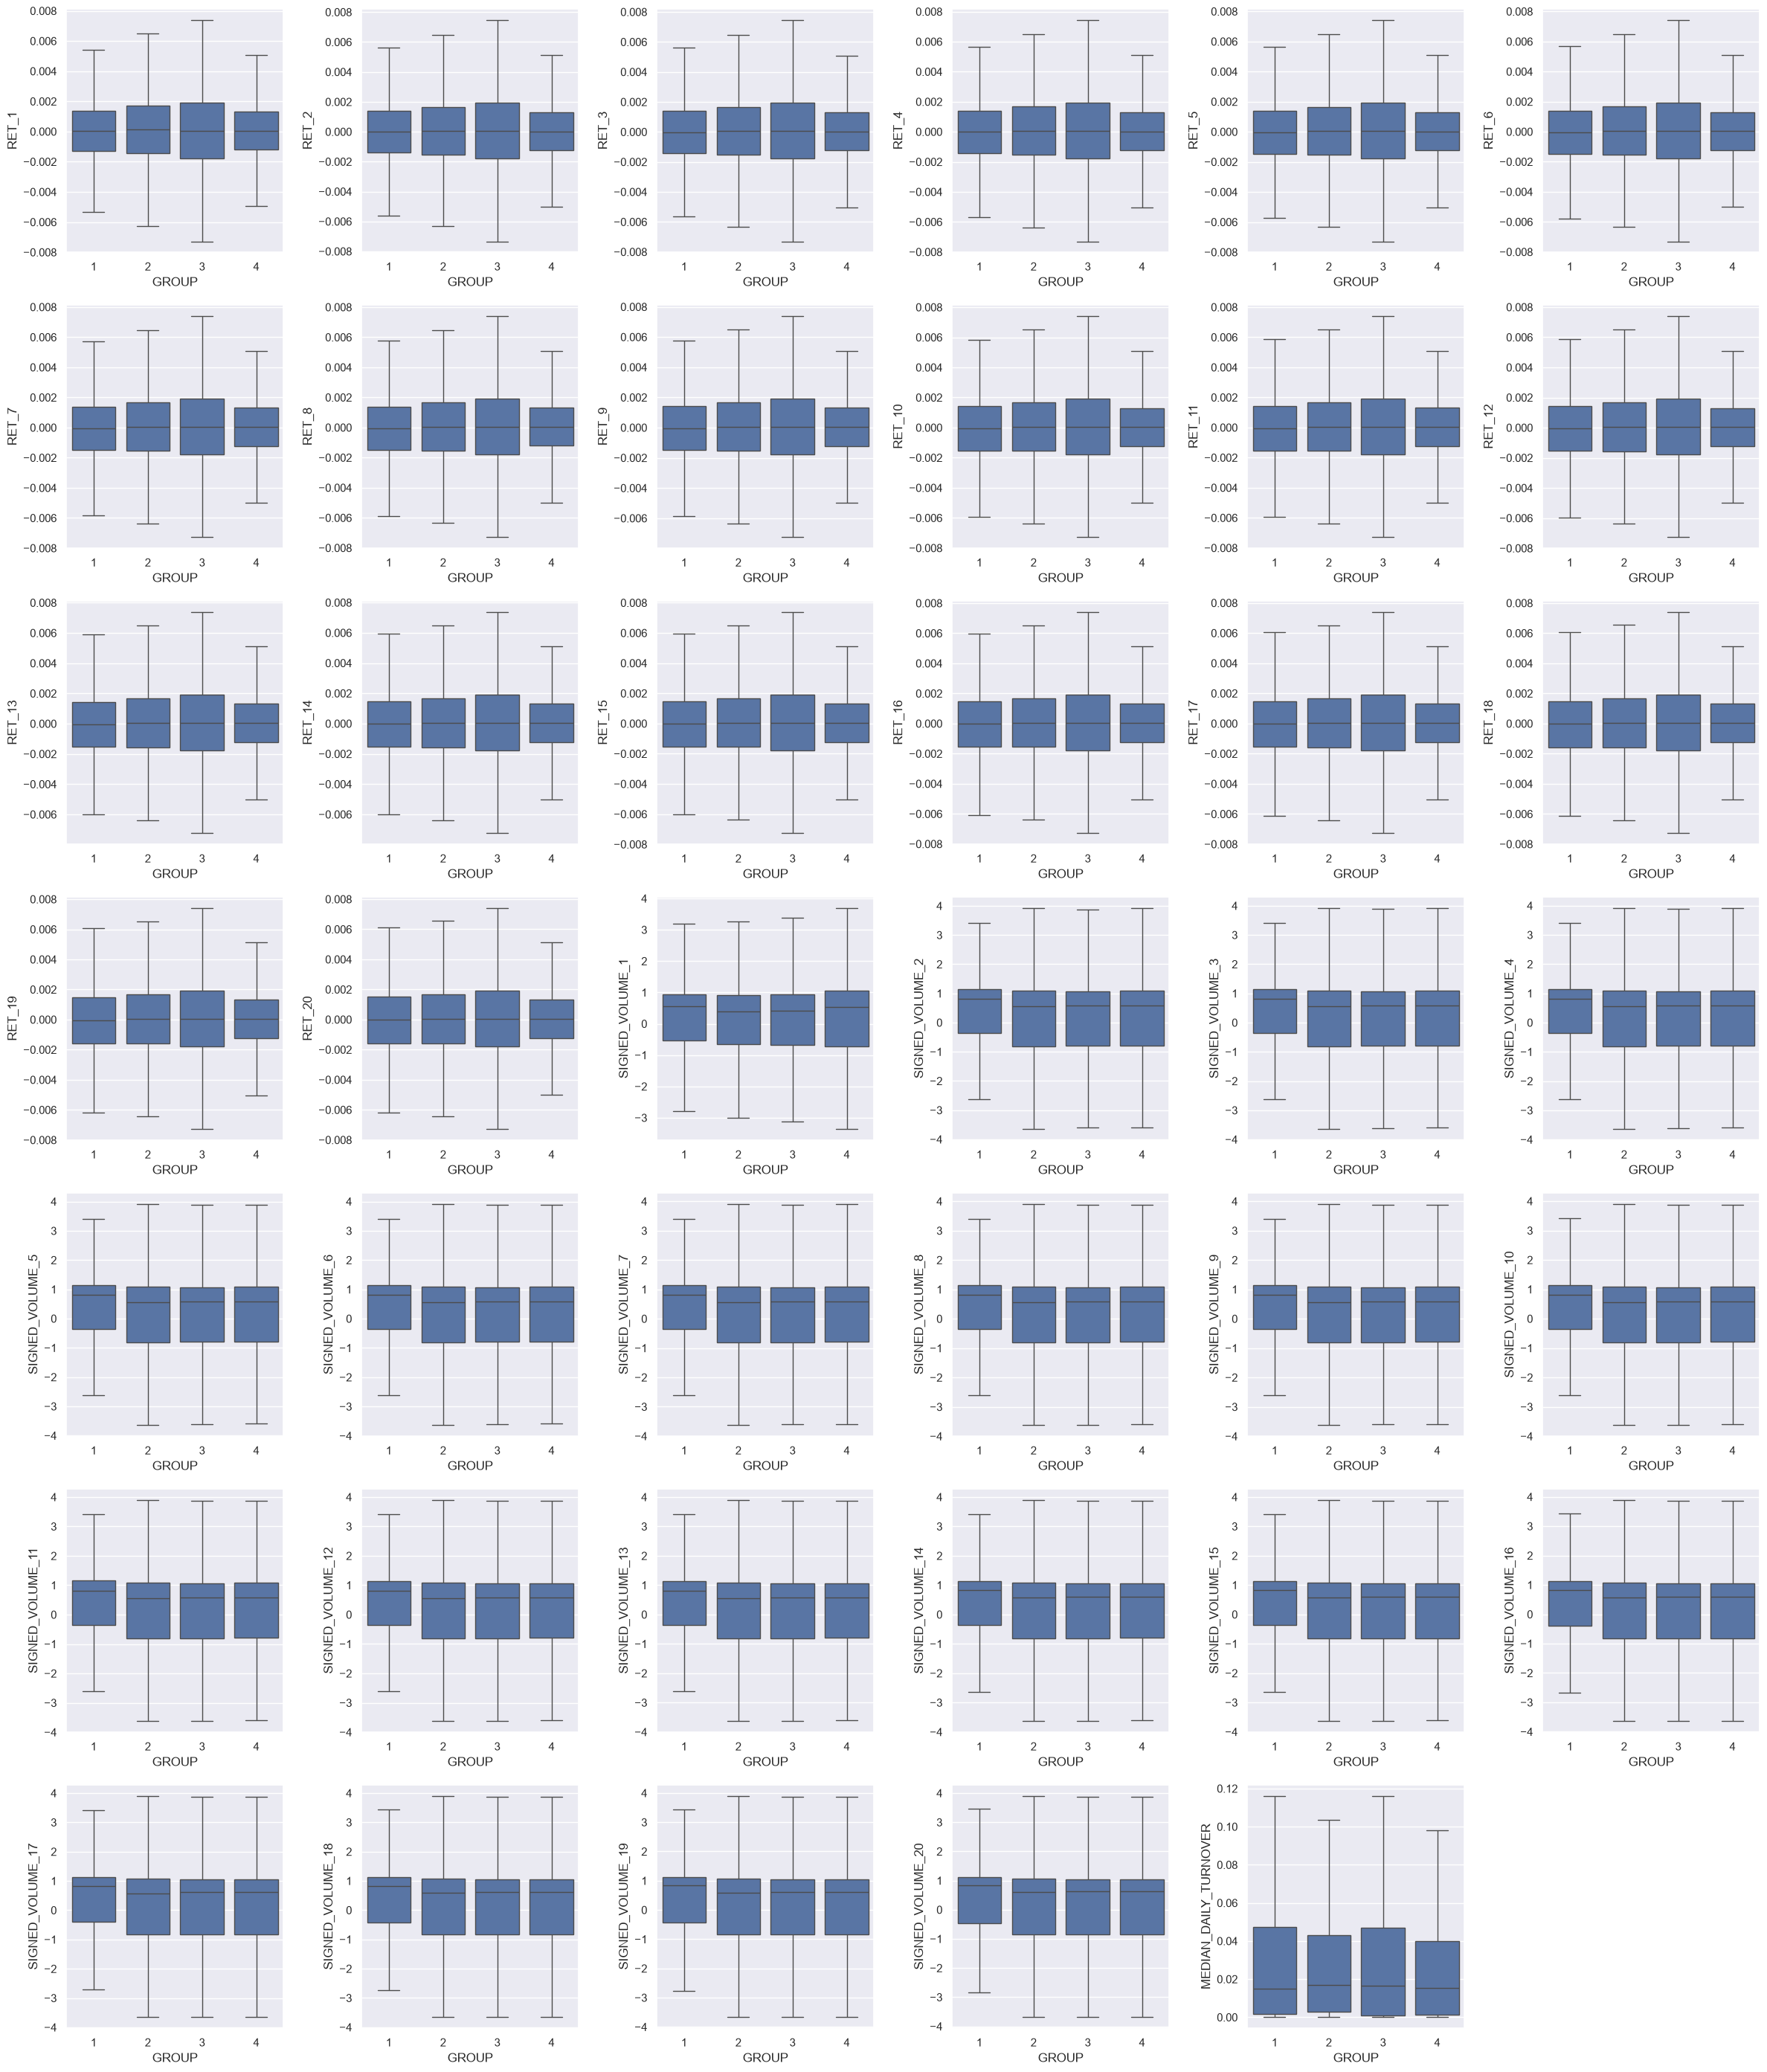

In [ ]:
fig, axes = plt.subplots(7, 6, figsize=(24, 28))

for i, column in enumerate(columns):
    sns.boxplot(data=X_train, x="GROUP", y=column, showfliers=False, ax=axes.flat[i])

fig.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

Les médianes des RET sont proches de zéro, mais les boîtes du groupe 3 sont généralement plus larges que celles du groupe 4.Les groupes ont des dispersions de rendements différentes. Pour RET_1, la boîte du groupe 3 est environ 47 % plus large.

Les corrélations entre RET sont faibles : 0,068 entre RET_1 et RET_2.Peu d’association linéaire entre les rendements passés dans l’ensemble des données.

Les volumes sont davantage corrélés : 0,644 entre les lags 2 et 3, contre 0,284 entre les lags 2 et 20.Les lags de volume partagent davantage d’information, particulièrement lorsqu’ils sont proches.

Les médianes du turnover sont proches : 0,015 à 0,017 selon le groupe.Le centre de sa distribution distingue assez peu les groupes.